In [2]:
!pip install enoslib ipywidgets --break-system-packages

Defaulting to user installation because normal site-packages is not writeable


In [1]:
!ssh rennes.grid5000.fr hostname

frennes


In [ ]:
!ssh-add ~/.ssh/id_ed25519

.ssh/id_ed25519: No such file or directory


### G5K connection

Setup the `.python-grid5000.yaml` file with the username and password used to login to grid5000.

The file should look like this:
```yaml
username: G5K_LOGIN
password: G5K_password
```

-> required in order for the enoslib calls to g5k to work.

In addition to this, make sure to add these lines to your ssh configuration:

```text
Host g5k
    User G5K_LOGIN
    HostName access.grid5000.fr
    ForwardAgent no

Host !access.grid5000.fr *.grid5000.fr
    User G5K_LOGIN
    ProxyJump G5K_LOGIN@access.grid5000.fr
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host access.grid5000.fr
    User G5K_LOGIN
    StrictHostKeyChecking no
    UserKnownHostsFile /dev/null
    ForwardAgent yes

Host *.g5k
    User G5K_LOGIN
    ProxyCommand ssh g5k -W "$(basename %h .g5k):%p"
    ForwardAgent no
```

Make sure to replace `G5K_LOGIN` with your g5k username (the one from the site)

### Job configuration

Setup the various parameters for the job:
- The job name will identify the current booking, if the notebook kernel dies, re running the same reservation code with the same name will reload the existing job instead of booking a new one
- The walltime is the time that the booking will last, you can always stop your reservation earlier than the booking's end time

In [1]:
import os
from grid5000 import Grid5000
import enoslib as en
import logging


conf_file = os.path.join(os.environ.get("HOME"), ".python-grid5000.yaml") # type: ignore
gk = Grid5000.from_yaml(conf_file)

# map each cluster to its site
cluster_to_site = {}
for site in gk.sites.list():
    for cluster in site.clusters.list():
        cluster_to_site[cluster.uid] = site.uid


# JOB CONFIGURATION
JOB_NAME="fcquic_multisite_GRE_testing"
JOB_WALLTIME="3:00:00"

NUM_SERVER_NODES=1
SERVER_CLUSTER="econome"

# number of network namespaces per client server (each ns runs one client binary)
NUM_NS_PER_CLIENT=5

CLIENT_CLUSTERS=[
    {"cluster": "parasilo", "num_clients": 2},
    {"cluster": "fleckenstein", "num_clients": 2},
]


# Display some general information about the library
en.check()
# Enable rich logging
_ = en.init_logging()
# en.set_config(g5k_auto_jump=False)

conf = (
    en.G5kConf.from_settings(
        job_name=JOB_NAME,
        walltime=JOB_WALLTIME,
        env_name="debian12-nfs",
        job_type=["deploy"],
    ) 

    # server router 
    .add_machine(
        roles=["router", "router_server"],
        cluster=SERVER_CLUSTER,
        nodes=1,
    )
    # server
    .add_machine(
        roles=["server"],
        cluster=SERVER_CLUSTER,
        nodes=NUM_SERVER_NODES,
    ) 
    .add_network(
        id="subnet_server",
        type="slash_22",
        roles=["subnet", "subnet_server"],
        site=cluster_to_site[SERVER_CLUSTER],
    )
)

# we need to add one client router + clients + subnet for client cluster
for i, client_cluster in enumerate(CLIENT_CLUSTERS):
    conf = (
        conf
        # add only one client router
        .add_machine(
            roles=["router", "router_client", f"router_client_{i}"],
            cluster=client_cluster["cluster"],
            nodes=1,
        )
        # add all of the client machines
        .add_machine(
            roles=["client", f"client_{i}"],
            cluster=client_cluster["cluster"],
            nodes=client_cluster["num_clients"],
        )
        .add_network(
            id=f"subnet_client_{i}",
            type="slash_22",
            roles=["subnet", "subnet_client", f"subnet_client_{i}"],
            site=cluster_to_site[client_cluster["cluster"]],
        )
    )

# This will validate the configuration, but not reserve resources yet
provider = en.G5k(conf)

[WARNING]: failed to patch stdout/stderr for fork-safety: 'OutStream' object
has no attribute 'buffer'
[WARNING]: failed to reconfigure stdout/stderr with custom encoding error
handler: 'OutStream' object has no attribute 'reconfigure'


_____        ___  ____  _ _ _
 | ____|_ __  / _ \/ ___|| (_) |__
 |  _| | '_ \| | | \___ \| | | '_ \
 | |___| | | | |_| |___) | | | |_) |
 |_____|_| |_|\___/|____/|_|_|_.__/  10.6.0

 • Documentation: ]8;id=953612;https://discovery.gitlabpages.inria.fr/enoslib/\https://discovery.gitlabpages.inria.fr/enoslib/]8;;\                            
 • Source: ]8;id=311454;https://gitlab.inria.fr/discovery/enoslib\https://gitlab.inria.fr/discovery/enoslib]8;;\                                         
 • Chat: ]8;id=624507;https://framateam.org/enoslib\https://framateam.org/enoslib]8;;\

                         Dependency check                         
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider      ┃    Status     ┃ Hint                           ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Chameleon     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonKVM  │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ ChameleonEdge │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Fabric        │ NOT INSTALLED │ pip install enoslib[fabric]    │
│ Distem        │ NOT INSTALLED │ pip install enoslib[distem]    │
│ IOT-lab       │ NOT INSTALLED │ pip install enoslib[iotlab]    │
│ Grid'5000     │   INSTALLED   │                                │
│ Openstack     │ NOT INSTALLED │ pip install enoslib[chameleon] │
│ Vagrant       │ NOT INSTALLED │ pip install enoslib[vagrant]   │
│ VMonG5k       │   INSTALLED   │                                │
└───────────────┴───────────────┴────────────────────────────────┘

                                Connectivity check                                 
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Provider  ┃ Key                 ┃ Connectivity ┃ Hint                           ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Grid'5000 │ ssh:access          │      ✅      │ Connection to access.grid5000… │
│ Grid'5000 │ ssh:access:frontend │      ✅      │ Connection Host(rennes.grid50… │
│ Grid'5000 │ api:access          │      ✅      │                                │
│ VMonG5k   │ access              │      ❔      │ Check G5k status               │
└───────────┴─────────────────────┴──────────────┴────────────────────────────────┘

In [2]:
print("Reserving resources...")

# Get actual resources
roles, networks = provider.init()
display(roles)
display(networks)

# Fill in network information from nodes
roles = en.sync_info(roles, networks)

with en.actions(roles=roles) as a:
    a.apt(task_name="Install iperf", name="iperf", state="present")
    a.apt(task_name="Install traceroute", name="traceroute", state="present")
    a.apt(task_name="Install tcpdump", name="tcpdump", state="present")

with en.actions(roles=roles["router"], gather_facts=True) as a:
    a.file(
        task_name="Ensure apt keyring directory exists",
        path="/usr/share/keyrings",
        state="directory",
        mode="0755",
    )
    a.get_url(
        task_name="Download FRR GPG key",
        url="https://deb.frrouting.org/frr/keys.gpg",
        dest="/usr/share/keyrings/frrouting.gpg",
        mode="0644",
    )
    a.apt_repository(
        task_name="Add FRR apt repository",
        repo="deb [signed-by=/usr/share/keyrings/frrouting.gpg] https://deb.frrouting.org/frr {{ ansible_distribution_release }} frr-stable",
        filename="frr",
        state="present",
    )
    a.apt(
        task_name="Install FRR packages",
        name=["frr", "frr-pythontools"],
        state="present",
        update_cache=True,
    )
    results = a.results

Reserving resources...


INFO     [G5k] Reloading 312835 from nantes                              ]8;id=439659;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=152890;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Reloading 3692329 from rennes                             ]8;id=430183;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=402597;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Reloading 41921 from strasbourg                           ]8;id=64090;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=282553;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Reloading 312835 from nantes                              ]8;id=978718;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=344112;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

...

Finished 3 tasks (Install iperf,Install traceroute,Install tcpdump) on 
{'parasilo-3.rennes.grid5000.fr', 'fleckenstein-5.strasbourg.grid5000.fr', 
'econome-20.nantes.grid5000.fr', 'econome-4.nantes.grid5000.fr', 
'parasilo-19.rennes.grid5000.fr', 'parasilo-14.rennes.grid5000.fr', 
'fleckenstein-1.strasbourg.grid5000.fr', 'fleckenstein-6.strasbourg.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Finished 5 tasks (Gather facts,Ensure apt keyring directory exists,Download FRR GPG key,Add 
FRR apt repository,Install FRR packages) on {'econome-20.nantes.grid5000.fr', 
'fleckenstein-1.strasbourg.grid5000.fr', 'parasilo-14.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

### Interface setup
- We first need to get the name of the primary interface for each node, this is the interface that is connected to the "prod" network
- Then we need to assign IPs from our subnet to the nodes


In [3]:
prod_interfaces_per_node = {}
# node_ips = {}

# find the physical interface connected to the production network
for host in roles["client"] + roles["server"] + roles["router"]:
    node_name = host.address

    prod_interfaces = host.filter_interfaces(networks=networks["prod"])    
    if prod_interfaces:
        prod_interface_name = prod_interfaces[0]
        print(f"Prod interface for {host.alias}: {prod_interface_name}")
        prod_interfaces_per_node[host.alias] = prod_interface_name


    else:
        print(f"Couldn't find prod iface for {host.alias}")
    
     
    # get each node's IP address on the production network
    # ip_address_obj = host.filter_addresses(networks=networks["prod"])[0]
    # # This may seem weird: ip_address_obj.ip is a `netaddr.IPv4Interface`
    # # which itself has an `ip` attribute.
    # node_ip = ip_address_obj.ip.ip
    # if node_ips.get(node_name) is None:
    #     node_ips[node_name] = []
    # node_ips[node_name].append(node_ip.exploded)
    # host.extra.update(ips=node_ips[node_name])


display(prod_interfaces_per_node)
# display(node_ips)

Prod interface for parasilo-3.rennes.grid5000.fr: eno1
Prod interface for econome-20.nantes.grid5000.fr: enp3s0f0
Prod interface for parasilo-14.rennes.grid5000.fr: eno1
Prod interface for fleckenstein-6.strasbourg.grid5000.fr: ens10f0
Prod interface for fleckenstein-5.strasbourg.grid5000.fr: ens10f0
Prod interface for parasilo-19.rennes.grid5000.fr: eno1
Prod interface for econome-4.nantes.grid5000.fr: enp3s0f0
Prod interface for fleckenstein-1.strasbourg.grid5000.fr: ens10f0


{'parasilo-3.rennes.grid5000.fr': 'eno1',
 'econome-20.nantes.grid5000.fr': 'enp3s0f0',
 'parasilo-14.rennes.grid5000.fr': 'eno1',
 'fleckenstein-6.strasbourg.grid5000.fr': 'ens10f0',
 'fleckenstein-5.strasbourg.grid5000.fr': 'ens10f0',
 'parasilo-19.rennes.grid5000.fr': 'eno1',
 'econome-4.nantes.grid5000.fr': 'enp3s0f0',
 'fleckenstein-1.strasbourg.grid5000.fr': 'ens10f0'}

### Assigning IPs from subnets

In [ ]:
from itertools import islice, product
import subprocess


node_ips = {}
# all namespace IPs across all client nodes (flat list for passing to NPF)
all_ns_ips = []

server_ips = networks["subnet_server"][0].free_ips

def assign_n_ips_to_hosts(role, N, ips):
    global node_ips

    for host in roles[role]:

        host_prod_iface = prod_interfaces_per_node[host.alias]
        host.extra.update(ips=[str(ip) for ip in islice(ips, N)])
        
        for ip in host.extra.get("ips"):

            print(f"Adding ip {ip} to host: {host.alias}")

            if node_ips.get(role) is None:
                node_ips[role] = []
            node_ips[role].append(ip)

            if "router" not in role:
                cmd = f"(ip a | grep {ip}) || ip addr add {ip}/32 dev {host_prod_iface}"
                en.run_command(cmd, task_name="cmd", roles=host, gather_facts=False)

        if "router" in role:
               
            # get each node's IP address on the production network
            ip_address_obj = host.filter_addresses(networks=networks["prod"])[0]
            # This may seem weird: ip_address_obj.ip is a `netaddr.IPv4Interface`
            # which itself has an `ip` attribute.
            node_ip = ip_address_obj.ip.ip
            if node_ips.get(role) is None:
                node_ips[role] = []
            node_ips[role].append(node_ip.exploded)
            host.extra.update(ips=node_ips[role])


def assign_ns_ips_to_clients(role, ips):
    # assign ip addresses of the client nodes
    global node_ips, all_ns_ips

    for host in roles[role]:
        ns_ips = [str(ip) for ip in islice(ips, NUM_NS_PER_CLIENT)]
        host.extra.update(ips=ns_ips)
        host.extra.update(ns_configs=[
            {"id": j, "ip": ns_ips[j]}
            for j in range(len(ns_ips))
        ])

        if node_ips.get(role) is None:
            node_ips[role] = []
        node_ips[role].extend(ns_ips)
        all_ns_ips.extend(ns_ips)

        print(f"Allocated {len(ns_ips)} namespace IP addresses for {host.alias}: {ns_ips}")


assign_n_ips_to_hosts("router_server", 1, server_ips)    
assign_n_ips_to_hosts("server", 1, server_ips)    

# assign ips to all clients and routers in each cluster
for i, client_cluster in enumerate(CLIENT_CLUSTERS):
    client_ips = networks[f"subnet_client_{i}"][0].free_ips
    assign_n_ips_to_hosts(f"router_client_{i}", 1, client_ips)    
    # allocate NUM_NS_PER_CLIENT IPs per client node (instead of 1)
    assign_ns_ips_to_clients(f"client_{i}", client_ips)


display(node_ips)
print(f"number of total ip addresses (i.e., indiviual client): {len(all_ns_ips)}")
display(all_ns_ips)

Adding ip 10.176.24.1 to host: econome-20.nantes.grid5000.fr
Adding ip 10.176.24.2 to host: econome-4.nantes.grid5000.fr
Adding ip 10.158.8.1 to host: parasilo-14.rennes.grid5000.fr
Allocated 5 namespace IP addresses for parasilo-19.rennes.grid5000.fr: ['10.158.8.2', '10.158.8.3', '10.158.8.4', '10.158.8.5', '10.158.8.6']
Allocated 5 namespace IP addresses for parasilo-3.rennes.grid5000.fr: ['10.158.8.7', '10.158.8.8', '10.158.8.9', '10.158.8.10', '10.158.8.11']
Adding ip 10.168.0.1 to host: fleckenstein-1.strasbourg.grid5000.fr
Allocated 5 namespace IP addresses for fleckenstein-5.strasbourg.grid5000.fr: ['10.168.0.2', '10.168.0.3', '10.168.0.4', '10.168.0.5', '10.168.0.6']
Allocated 5 namespace IP addresses for fleckenstein-6.strasbourg.grid5000.fr: ['10.168.0.7', '10.168.0.8', '10.168.0.9', '10.168.0.10', '10.168.0.11']


{'router_server': ['10.176.24.1', '172.16.192.20'],
 'server': ['10.176.24.2'],
 'router_client_0': ['10.158.8.1', '172.16.97.14'],
 'client_0': ['10.158.8.2',
  '10.158.8.3',
  '10.158.8.4',
  '10.158.8.5',
  '10.158.8.6',
  '10.158.8.7',
  '10.158.8.8',
  '10.158.8.9',
  '10.158.8.10',
  '10.158.8.11'],
 'router_client_1': ['10.168.0.1', '172.16.160.1'],
 'client_1': ['10.168.0.2',
  '10.168.0.3',
  '10.168.0.4',
  '10.168.0.5',
  '10.168.0.6',
  '10.168.0.7',
  '10.168.0.8',
  '10.168.0.9',
  '10.168.0.10',
  '10.168.0.11']}

number of total ip addresses (i.e., indiviual client): 20


['10.158.8.2',
 '10.158.8.3',
 '10.158.8.4',
 '10.158.8.5',
 '10.158.8.6',
 '10.158.8.7',
 '10.158.8.8',
 '10.158.8.9',
 '10.158.8.10',
 '10.158.8.11',
 '10.168.0.2',
 '10.168.0.3',
 '10.168.0.4',
 '10.168.0.5',
 '10.168.0.6',
 '10.168.0.7',
 '10.168.0.8',
 '10.168.0.9',
 '10.168.0.10',
 '10.168.0.11']

### Client network namespace setup (MACVLAN)

Each client node gets `NUM_NS_PER_CLIENT` network namespaces connected to the prod interface via a MACVLAN "bridge", which is not really a bridge. Using bridges and virtual ethernet would probs work but it's such a mess

In [ ]:
from ipaddress import ip_address, ip_network

all_client_roles = [f"client_{i}" for i in range(len(CLIENT_CLUSTERS))]

# tear down previous network namespace or macvlan
for role in all_client_roles:
    with en.play_on(roles=roles, pattern_hosts=role, gather_facts=False) as p:
        p.shell(
            """
            for ns in $(ip netns list 2>/dev/null | awk '{print $1}'); do
                ip netns del "$ns" 2>/dev/null || true
            done


            for link in $(ip -o link show type macvlan | awk -F': ' '{print $2}'); do
                ip link del "$link" 2>/dev/null || true
            done
            """,
            task_name="cleanup_namespaces",
        )

# creating the namespaces:
# we need the gateway IP per cluster for the default routes of the namespaces
# the router's subnet IP (10.xzy) is in the same /22 subnet as the namespace IPS
# so we use that as the gateway (the global/prod IP is on a different subnet).
gateway_ip_per_cluster = {}
for i in range(len(CLIENT_CLUSTERS)):
    router_role = f"router_client_{i}"
    local_subnet = ip_network('10.0.0.0/8')
    host_ips = [str(ip) for ip in node_ips[router_role] if ip_address(ip) in local_subnet]
    if not host_ips:
        raise RuntimeError(f"No subnet IP for {router_role}")
    gateway_ip_per_cluster[i] = host_ips[0]

for i, client_cluster in enumerate(CLIENT_CLUSTERS):
    role = f"client_{i}"
    gateway_ip = gateway_ip_per_cluster[i]
    print(f"gateway_ip={gateway_ip} for client {role}")

    for host in roles[role]:
        prod_iface = prod_interfaces_per_node[host.alias]
        # store prod_iface and gateway in extra so we can use them in the jinja template of en.play_on (see enoslib docs on ansible)
        host.extra.update(prod_iface=prod_iface, ns_gateway=gateway_ip)

    with en.play_on(roles=roles, pattern_hosts=role, gather_facts=False) as p:
        # NOTE: the commands below will run as root iif the ssh keys setup in g5k are present on the current machine
        p.shell(
            """
            NS_NAME="client-{{ item.id }}"
            MACVLAN_HOST="mv-c{{ item.id }}"
            MACVLAN_NS="eth0"
            IP_ADDR="{{ item.ip }}"
            PROD_IFACE="{{ prod_iface }}"
            GATEWAY="{{ ns_gateway }}"

            ip netns add "$NS_NAME"

            # create a MACVLAN interface on the prod interface
            ip link add "$MACVLAN_HOST" link "$PROD_IFACE" type macvlan mode bridge
            ip link set "$MACVLAN_HOST" netns "$NS_NAME"

            # configure the netns interface
            ip netns exec "$NS_NAME" ip link set "$MACVLAN_HOST" name "$MACVLAN_NS"
            ip netns exec "$NS_NAME" ip addr add "$IP_ADDR"/22 dev "$MACVLAN_NS"
            ip netns exec "$NS_NAME" ip link set "$MACVLAN_NS" up
            ip netns exec "$NS_NAME" ip link set lo up
            ip netns exec "$NS_NAME" ip link set "$MACVLAN_NS" multicast on
            ip netns exec "$NS_NAME" ip route add default via "$GATEWAY" dev "$MACVLAN_NS"
            """,
            loop="{{ ns_configs }}",
            task_name="create_macvlan_namespaces",
        )

    print(f"Created {len(roles[role]) * NUM_NS_PER_CLIENT} namespaces for {role} (gateway {gateway_ip})")

Output()

Finished 1 tasks (cleanup_namespaces) on {'parasilo-3.rennes.grid5000.fr', 
'parasilo-19.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

Finished 1 tasks (cleanup_namespaces) on {'fleckenstein-5.strasbourg.grid5000.fr', 
'fleckenstein-6.strasbourg.grid5000.fr'}

...

Output()

Created 10 namespaces for client_0 (gateway 10.158.8.1)
gateway_ip=10.168.0.1 for client client_1


Finished 1 tasks (create_macvlan_namespaces) on {'fleckenstein-5.strasbourg.grid5000.fr', 
'fleckenstein-6.strasbourg.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Created 10 namespaces for client_1 (gateway 10.168.0.1)


### GRE Tunnels setup


In [8]:
from ipaddress import ip_network, ip_address


router_server_host = roles["router_server"][0]
router_server_alias = router_server_host.address

router_server_prod_iface = prod_interfaces_per_node.get(router_server_alias)
if router_server_prod_iface is None:
    # we dont use exit because that kills the kernel i think
    raise RuntimeError(f"No prod interface for node '{router_server_alias}'")


def get_node_prod_ip(host, role: str) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the global address, we filter out the local address
    host_ips = [str(ip) for ip in host.extra.get("ips", []) if ip_address(ip) not in local_subnet]
    if host_ips:
        return host_ips[0]

    raise RuntimeError(f"Could get prod ip for '{host.address}'")


router_server_prod_ip = get_node_prod_ip(router_server_host, "router_server")

# store info used later in the router conf
# {gre_iface, server_tunnel_ip, client_tunnel_ip, tunnel_subnet, client_cluster_idx}
tunnel_info = []

# one gre tunnel per client cluster
server_gre_cmds = []

tunnel_base = int(ip_address("192.168.0.0"))

for i, client_cluster in enumerate(CLIENT_CLUSTERS):
    router_client_host = roles[f"router_client_{i}"][0]
    router_client_alias = router_client_host.address

    router_client_prod_iface = prod_interfaces_per_node.get(router_client_alias)
    if router_client_prod_iface is None:
        raise RuntimeError(f"No prod interface for node '{router_client_alias}'")

    router_client_prod_ip = get_node_prod_ip(router_client_host, f"router_client_{i}")

    # NOTE: the tunnels have local addresses assigned for each endpoint, we use a /30 prefix for each tunnel
    # i don't really know if those addresses must be unique accross all tunnels
    tunnel_subnet = ip_network((tunnel_base + i * 4, 30))
    server_tunnel_ip = str(tunnel_subnet.network_address + 1)
    client_tunnel_ip = str(tunnel_subnet.network_address + 2)

    server_gre_iface = f"gre{i + 1}"
    client_gre_iface = "gre1"

    tunnel_info.append({
        "idx": i,
        "server_gre_iface": server_gre_iface,
        "client_gre_iface": client_gre_iface,
        "server_tunnel_ip": server_tunnel_ip,
        "client_tunnel_ip": client_tunnel_ip,
        "tunnel_subnet": tunnel_subnet,
        "router_client_host": router_client_host,
        "router_client_prod_ip": router_client_prod_ip,
    })

    # server side GRE commands
    server_gre_cmds.extend([
        f"sudo ip link del {server_gre_iface} 2>/dev/null || true",
        f"sudo ip tunnel add {server_gre_iface} mode gre local {router_server_prod_ip} remote {router_client_prod_ip} ttl 255",
        f"sudo ip addr add {server_tunnel_ip}/30 dev {server_gre_iface}",
        f"sudo ip link set {server_gre_iface} up",
        f"sudo ip link set {server_gre_iface} multicast on",
        f"sudo sysctl -w net.ipv4.conf.{server_gre_iface}.rp_filter=0",
    ])

    # client side GRE commands
    # NOTE: the client routers always use gre1 as the name for their gre tunnel to the server router
    router_client_cmd = "; ".join([
        f"sudo ip link del {client_gre_iface} 2>/dev/null || true",
        f"sudo ip tunnel add {client_gre_iface} mode gre local {router_client_prod_ip} remote {router_server_prod_ip} ttl 255",
        f"sudo ip addr add {client_tunnel_ip}/30 dev {client_gre_iface}",
        f"sudo ip link set {client_gre_iface} up",
        f"sudo ip link set {client_gre_iface} multicast on",
        f"sudo sysctl -w net.ipv4.conf.{client_gre_iface}.rp_filter=0",
        "sudo sysctl -w net.ipv4.conf.all.rp_filter=0",
    ])
    en.run_command(router_client_cmd, task_name=f"setup_{router_client_alias}_{client_gre_iface}", roles=router_client_host, gather_facts=False)

    print(f"GRE tunnel {server_gre_iface}<->{client_gre_iface}: "
          f"{router_server_alias}({server_tunnel_ip}) <-> {router_client_alias}({client_tunnel_ip})")

# then once all the client router tunnels are created, we can create the server router tunnel
server_gre_cmds.append("sudo sysctl -w net.ipv4.conf.all.rp_filter=0")
en.run_command("; ".join(server_gre_cmds), task_name=f"setup_{router_server_alias}_all_gre", roles=router_server_host, gather_facts=False)

display(tunnel_info)


Output()

Finished 1 tasks (setup_parasilo-14.rennes.grid5000.fr_gre1) on 
{'parasilo-14.rennes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

GRE tunnel gre1<->gre1: econome-20.nantes.grid5000.fr(192.168.0.1) <-> parasilo-14.rennes.grid5000.fr(192.168.0.2)


...

Output()

GRE tunnel gre2<->gre1: econome-20.nantes.grid5000.fr(192.168.0.5) <-> fleckenstein-1.strasbourg.grid5000.fr(192.168.0.6)


Finished 1 tasks (setup_econome-20.nantes.grid5000.fr_all_gre) on 
{'econome-20.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

[{'idx': 0,
  'server_gre_iface': 'gre1',
  'client_gre_iface': 'gre1',
  'server_tunnel_ip': '192.168.0.1',
  'client_tunnel_ip': '192.168.0.2',
  'tunnel_subnet': IPv4Network('192.168.0.0/30'),
  'router_client_host': Host(address='parasilo-14.rennes.grid5000.fr', alias='parasilo-14.rennes.grid5000.fr', user='root', keyfile=None, port=None, extra={'gateway': 'access.grid5000.fr', 'gateway_user': 'cdetry', 'ips': ['10.158.8.1', '172.16.97.14']}, net_devices={NetDevice(name='lo', addresses={IPAddress(network=None, ip=IPv4Interface('127.0.0.1/8')), IPAddress(network=None, ip=IPv6Interface('::1/128'))}), NetDevice(name='eno3', addresses=set()), NetDevice(name='eno4', addresses=set()), NetDevice(name='eno2', addresses=set()), NetDevice(name='eno1', addresses={IPAddress(network=None, ip=IPv6Interface('fe80::eef4:bbff:fed1:590/64')), IPAddress(network=<enoslib.infra.enos_g5k.objects.G5kEnosProd4Network object at 0x7a2e5027c740>, ip=IPv4Interface('172.16.97.14/20'))})}, _Host__original_extra

### FRR Routing setup

In [9]:
from ipaddress import ip_address, ip_network
from pathlib import Path
import subprocess
from jinja2 import Template


# first entry is server router, then one entry per client cluster
ROUTER_MAPPING: list[tuple[str, str, bool, None | int]] = [
    # (role, subnet_key, is_server, cluster_idx)
    ("router_server", "subnet_server", True, None),
]
for i in range(len(CLIENT_CLUSTERS)):
    ROUTER_MAPPING.append((f"router_client_{i}", f"subnet_client_{i}", False, i))

TEMPLATE_FILE = "base_router_config_ospf.frr"
DAEMONS_FILE = "./daemons"
OUTPUT_DIR = Path("./generated_frr_configs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with open(TEMPLATE_FILE, "r", encoding="utf-8") as f:
    template = Template(f.read())

def parse_subnet(subnet_obj):
    for attr in ("network", "cidr", None):
        val = str(getattr(subnet_obj, attr, subnet_obj)) if attr else str(subnet_obj)
        if not val:
            continue
        try:
            return ip_network(val if "/" in val else f"{val}/22", strict=False)
        except ValueError:
            continue
    raise ValueError(f"Can't parse subnet: {subnet_obj!r}")


def get_router_subnet_ip(host, role: str) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the LOCAL address here, we only keep addresses in the 10.../8 block
    host_ips = [str(ip) for ip in host.extra.get("ips", []) if ip_address(ip) in local_subnet]
    if host_ips:
        return host_ips[0]

    role_ips = [str(ip) for ip in node_ips.get(role, [])]
    if role_ips:
        return role_ips[0]

    raise ValueError(f"Could get prod ip for '{host.address}'")

def get_router_global_ip(host, role: str) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the global address here, we discard all IPs in that subnet
    host_ips = [str(ip) for ip in host.extra.get("ips", []) if ip_address(ip) not in local_subnet]
    if host_ips:
        return host_ips[0]

    role_ips = [str(ip) for ip in node_ips.get(role, [])]
    if role_ips:
        return role_ips[0]

    raise ValueError(f"Could get prod ip for '{host.address}'")

def get_default_gateway(address):
    # get the default gateway from the node via ssh
    # could just hardcode these values based on the info on the website...
    result = subprocess.run(
        ["ssh", address, "ip -4 route show default"],
        capture_output=True, text=True, check=False,
    )
    if result.returncode != 0 or not result.stdout.strip():
        raise RuntimeError(f"No default route on {address}: {result.stderr.strip()}")

    out = result.stdout.strip().splitlines()[0].split()
    if "via" not in out:
        raise RuntimeError(f"No gateway used in the default route: {address}")
    
    return out[out.index("via") + 1]


def pick_loopback(subnet_obj, reserved):
    # since the booked subnets are /22, we get 3 different /24 subnets, so we just make sure that the routers have a loopback address in a 
    # /24 subnet that we wont pick for the clients, just to be safe
    subnet = parse_subnet(subnet_obj)
    for ip_int in range(int(subnet.broadcast_address) - 1, int(subnet.network_address), -1):
        candidate = str(ip_address(ip_int))
        if candidate not in reserved:
            return candidate
    raise ValueError(f"No free loopback in {subnet}")


router_configs = {}
router_loopbacks = {}
router_gateways = {}
reserved_ips = {str(ip) for ips in node_ips.values() for ip in ips}

for idx, (role, subnet_key, is_server, cluster_idx) in enumerate(ROUTER_MAPPING):

    if not(subnet_key in networks and networks[subnet_key]):
        raise RuntimeError(f"Missing subnet {subnet_key}")

    host = roles[role][0]
    iface = prod_interfaces_per_node[host.address]
    subnet_obj = networks[subnet_key][0]

    prod_ip = get_router_subnet_ip(host, role)
    global_ip = get_router_global_ip(host, role)
    net_addr = str(parse_subnet(subnet_obj).network_address)
    lo_addr = pick_loopback(subnet_obj, reserved_ips)
    reserved_ips.add(lo_addr)
    gateway = get_default_gateway(host.address)

    router_id = idx + 1

    # REMINDER: highest bsr priority wins
    # but lowest rp priority wins
    bsr_prio = router_id + 100 if is_server else router_id
    rp_prio = 0 if is_server else router_id + 100

    # the server has a list of tunnels that we must fill in the template
    if is_server:
        tunnels = []
        for tun in tunnel_info:
            tunnels.append({
                "iface": tun["server_gre_iface"],
                "ip": tun["server_tunnel_ip"],
                "network": str(tun["tunnel_subnet"].network_address),
            })
    else:
        # the clients have only one tunnel though
        tun = tunnel_info[cluster_idx]
        tunnels = [{
            "iface": tun["client_gre_iface"],
            "ip": tun["client_tunnel_ip"],
            "network": str(tun["tunnel_subnet"].network_address),
        }]

    config = template.render(
        lo_address=lo_addr,
        prod_iface=iface,
        prod_net_ip=prod_ip,
        global_ip=global_ip,
        prod_network=net_addr,
        tunnels=tunnels,
        router_id=f"{router_id}.{router_id}.{router_id}.{router_id}",
        isis_router_id=router_id + 1,
        rp_prio=rp_prio,
        bsr_prio=bsr_prio,
        gateway=gateway,
    )

    router_configs[host.address] = config
    router_loopbacks[host.address] = lo_addr
    router_gateways[host.address] = gateway

    # write and deploy
    local_path = OUTPUT_DIR / f"{host.address.replace('/', '_')}.frr.conf"
    local_path.write_text(config, encoding="utf-8")

    remote = f"root@{host.address}:/etc/frr"
    subprocess.run(["scp", str(local_path), f"{remote}/frr.conf"], check=True)
    subprocess.run(["scp", DAEMONS_FILE, f"{remote}/daemons"], check=True)
    en.run_command("sudo systemctl restart frr", task_name=f"restart_frr_{host.address}", roles=host, gather_facts=False)

    print(f"[{role}] {host.address}  prod={prod_ip}  loopback={lo_addr}  gateway={gateway}")

display(router_loopbacks)
display(router_gateways)
display(router_configs)

Output()

Finished 1 tasks (restart_frr_econome-20.nantes.grid5000.fr) on 
{'econome-20.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

[router_server] econome-20.nantes.grid5000.fr  prod=10.176.24.1  loopback=10.176.27.254  gateway=172.16.207.254


Output()

...

─────────────────────────────────────────────────────────────────────────────────────────────

[router_client_1] fleckenstein-1.strasbourg.grid5000.fr  prod=10.168.0.1  loopback=10.168.3.254  gateway=172.16.175.254


{'econome-20.nantes.grid5000.fr': '10.176.27.254',
 'parasilo-14.rennes.grid5000.fr': '10.158.11.254',
 'fleckenstein-1.strasbourg.grid5000.fr': '10.168.3.254'}

{'econome-20.nantes.grid5000.fr': '172.16.207.254',
 'parasilo-14.rennes.grid5000.fr': '172.16.111.254',
 'fleckenstein-1.strasbourg.grid5000.fr': '172.16.175.254'}

{'econome-20.nantes.grid5000.fr': "frr defaults traditional\n!\nip forwarding\n!\nip prefix-list multicast permit 224.0.0.0/4\n\nip prefix-list ospf_out seq 5 deny 172.16.0.0 ge 16 le 22 \nip prefix-list ospf_out seq 10 permit any\n\n!\nip route 172.16.0.0/16 172.16.207.254 1\n!\ninterface lo\n    ip address 10.176.27.254/32\n    ip igmp\n    ip pim\n    ! ip ospf area 0\n    ip igmp immediate-leave\n!\ninterface enp3s0f0\n    ip address 10.176.24.1/24\n    ip pim\n    ip igmp\n    ip igmp immediate-leave\n    ! ip ospf area 0 ! Don't use this line when using the network xyz commands otherwise those don't apply and the prefix list doesn't either\n    ip ospf passive\n!\n\ninterface gre1\n    ip address 192.168.0.1/30\n    ip pim\n    ip igmp\n    ip igmp immediate-leave\n    ! ip ospf area 0\n    ip ospf network point-to-point\n    tunnel source enp3s0f0\n!\n\ninterface gre2\n    ip address 192.168.0.5/30\n    ip pim\n    ip igmp\n    ip igmp immediate-leave\n    ! ip ospf area 0\n    

### Default route setup on the non router nodes

In [10]:
import subprocess

import enoslib

# gateway mapping: each client_i -> router_client_i, the server has router_server as gateway ofc
gateway_router_role = {"server": "router_server"}
for i in range(len(CLIENT_CLUSTERS)):
    gateway_router_role[f"client_{i}"] = f"router_client_{i}"


def get_node_prod_ip(router_role) -> str:
    local_subnet = ip_network('10.0.0.0/8') # the subnets we get are in 10..../8, can't be more specific than that sadly
    # since we fetched the global address for the routers and assigned them a local address
    # and we want the global address, we filter out the local address

    host_ips = [str(ip) for ip in node_ips[router_role] if ip_address(ip) not in local_subnet]
    if host_ips:
        return host_ips[0]
    raise RuntimeError(f"Could get prod ip for {router_role}")

route_changes = []

# Set default route for the SERVER nodes only (on the host itself).
# Client nodes have their default routes configured inside their namespaces
# in the MACVLAN setup cell above.
for role, router_role in gateway_router_role.items():
    if role not in roles or not roles[role]:
        continue

    # # skip client roles — their routes are handled per-namespace
    # if role.startswith("client"):
    #     continue

    if router_role not in node_ips or not node_ips[router_role]:
        raise RuntimeError(f"Missing gateway IP for router role '{router_role}'")

    gateway_ip = get_node_prod_ip(router_role)
    print(gateway_ip)

    for host in roles[role]:
        host_iface = prod_interfaces_per_node.get(host.address)
        if host_iface is None:
            raise RuntimeError(f"Missing prod interface for node '{host.address}'")

        cmd = "; ".join(
            [
                f"sudo ip route replace default via {gateway_ip} dev {host_iface}",
                "sudo ip route flush cache",
                "ip route show default",
            ]
        )

        out = en.run_command(
            cmd,
            task_name=f"route_default_via_{router_role}_{host.address}",
            roles=host,
            gather_facts=False,
        )
        print([res.stderr for res in out.filter(status=enoslib.STATUS_FAILED)])

        route_changes.append(
            {
                "host": host.address,
                "role": role,
                "gateway_router_role": router_role,
                "gateway_ip": gateway_ip,
                "interface": host_iface,
            }
        )
        print(f"Default route for {host.address} now is {gateway_ip} on {host_iface}")

display(route_changes)

Output()

172.16.192.20


Finished 1 tasks (route_default_via_router_server_econome-4.nantes.grid5000.fr) on 
{'econome-4.nantes.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

Output()

...

[]
Default route for fleckenstein-5.strasbourg.grid5000.fr now is 172.16.160.1 on ens10f0


Finished 1 tasks (route_default_via_router_client_1_fleckenstein-6.strasbourg.grid5000.fr) on
{'fleckenstein-6.strasbourg.grid5000.fr'}

─────────────────────────────────────────────────────────────────────────────────────────────

[]
Default route for fleckenstein-6.strasbourg.grid5000.fr now is 172.16.160.1 on ens10f0


[{'host': 'econome-4.nantes.grid5000.fr',
  'role': 'server',
  'gateway_router_role': 'router_server',
  'gateway_ip': '172.16.192.20',
  'interface': 'enp3s0f0'},
 {'host': 'parasilo-3.rennes.grid5000.fr',
  'role': 'client_0',
  'gateway_router_role': 'router_client_0',
  'gateway_ip': '172.16.97.14',
  'interface': 'eno1'},
 {'host': 'parasilo-19.rennes.grid5000.fr',
  'role': 'client_0',
  'gateway_router_role': 'router_client_0',
  'gateway_ip': '172.16.97.14',
  'interface': 'eno1'},
 {'host': 'fleckenstein-5.strasbourg.grid5000.fr',
  'role': 'client_1',
  'gateway_router_role': 'router_client_1',
  'gateway_ip': '172.16.160.1',
  'interface': 'ens10f0'},
 {'host': 'fleckenstein-6.strasbourg.grid5000.fr',
  'role': 'client_1',
  'gateway_router_role': 'router_client_1',
  'gateway_ip': '172.16.160.1',
  'interface': 'ens10f0'}]

### Compiling and pushing binaries with SCP

In [11]:
!cd /home/corentin/fcquic_applications_master_thesis/fcquic_chat && cargo build --release 

   --> /home/corentin/fcquic_applications_master_thesis/multicast-quic/octets/src/lib.rs:474:22
    |
474 |     pub fn get_bytes(&mut self, len: usize) -> Result<Octets> {
    |                      ^^^^^^^^^                        ^^^^^^ the same lifetime is hidden here
    |                      |
    |                      the lifetime is elided here
    |
    = help: the same lifetime is referred to in inconsistent ways, making the signature confusing
    = note: `#[warn(mismatched_lifetime_syntaxes)]` on by default
help: use `'_` for type paths
    |
474 |     pub fn get_bytes(&mut self, len: usize) -> Result<Octets<'_>> {
    |                                                             ++++

   --> /home/corentin/fcquic_applications_master_thesis/multicast-quic/octets/src/lib.rs:491:26
    |
491 |     pub fn get_bytes_mut(&mut self, len: usize) -> Result<OctetsMut> {
    |                          ^^^^^^^^^                        ^^^^^^^^^ the same lifetime is hidden here
    | 

In [12]:
import subprocess

cert_dir = "/home/corentin/fcquic_applications_master_thesis/fcquic_chat"
# cert_dir = "/home/corentin/FFSexp3-master-thesis/multicast"
local_bin_dir = f"{cert_dir}/target/release"
remote_bin_dir = "/home/cdetry"

all_clients = [host for i in range(len(CLIENT_CLUSTERS)) for host in roles[f"client_{i}"]]

for node in all_clients + roles["server"]:
    host = node.alias
    print(f"pushing binary to {host}")

    subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/bin"], check=True)
    subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/logs/client"], check=True)
    subprocess.run(["ssh", host, f"mkdir -p {remote_bin_dir}/logs/server"], check=True)
    
    # subprocess.run(["scp", f"{local_bin_dir}/source", f"{host}:{remote_bin_dir}/bin/source"], check=True)
    # subprocess.run(["scp", f"{local_bin_dir}/receiver", f"{host}:{remote_bin_dir}/bin/receiver"], check=True)
    subprocess.run(["scp", f"{local_bin_dir}/server", f"{host}:{remote_bin_dir}/bin/server"], check=True)
    subprocess.run(["scp", f"{local_bin_dir}/client", f"{host}:{remote_bin_dir}/bin/client"], check=True)
    subprocess.run(["scp", f"{cert_dir}/cert.crt", f"{host}:{remote_bin_dir}/cert.crt"], check=True)
    subprocess.run(["scp", f"{cert_dir}/cert.key", f"{host}:{remote_bin_dir}/cert.key"], check=True)
        
print("pushed binaries to all nodes")

pushing binary to econome-4.nantes.grid5000.fr


pushing binary to fleckenstein-6.strasbourg.grid5000.fr


pushing binary to parasilo-3.rennes.grid5000.fr


pushing binary to fleckenstein-5.strasbourg.grid5000.fr


pushing binary to parasilo-19.rennes.grid5000.fr


pushed binaries to all nodes


### Running the experiment

In [10]:
import datetime
from npf import enoslib as enoslib
import npf.globals
from importlib import reload

reload(npf)

# IMPORTANT: if you run this cell multiple times, you must clear the global roles dictionary kept by NPF otherwise it will keep appending the nodes to it and this dict. will keep growing
# leading to each client being ran multiple times....
npf.globals.roles.clear()

# all_ns_ips was built in the IP assignment cell and contains every namespace IP
print(f"Total client IPs (namespaces): {len(all_ns_ips)}")

# Build npf_roles: client nodes need user="root" because sudo isn't available
# on the default user account, and NPF needs root to run commands in namespaces.
npf_roles = {}
for role, hosts in roles.items():
    if role.startswith("client"):
        npf_roles[role] = [
            en.Host(h.address, alias=h.alias, user="root", extra=h.extra)
            for h in hosts
        ]
    else:
        npf_roles[role] = hosts

print("Launching NPF")
now = str(datetime.datetime.now())
results, _ = enoslib.run(
    "test_gre_tunnels.npf",
    # Don't use series, it kinda breaks the whole test
    # series=[
    #     f"local",
    # ], 
    argsv= [
        "--single-output",
        f"./npf-out/{now}.csv",
        "--no-graph",
        "--force-retest",
        f"--variables",
            f"SERVER_IP={node_ips['server'][0]}", 
            f"CLIENT_IPS=({' '.join(all_ns_ips)})",
            # f"NUM_NS_PER_CLIENT={NUM_NS_PER_CLIENT}",
            f"NUM_NS_PER_CLIENT={1}",
            f'USE_DOCKER="false"',
    ],
    roles=npf_roles,
)

Total client IPs (namespaces): 20
Launching NPF
cluster/parasilo-14.rennes.grid5000.fr.node could not be found, we will connect to parasilo-14.rennes.grid5000.fr with SSH using default parameters
cluster/fleckenstein-1.strasbourg.grid5000.fr.node could not be found, we will connect to fleckenstein-1.strasbourg.grid5000.fr with SSH using default parameters
cluster/econome-20.nantes.grid5000.fr.node could not be found, we will connect to econome-20.nantes.grid5000.fr with SSH using default parameters
cluster/econome-20.nantes.grid5000.fr.node could not be found, we will connect to econome-20.nantes.grid5000.fr with SSH using default parameters
cluster/econome-4.nantes.grid5000.fr.node could not be found, we will connect to econome-4.nantes.grid5000.fr with SSH using default parameters
cluster/parasilo-14.rennes.grid5000.fr.node could not be found, we will connect to parasilo-14.rennes.grid5000.fr with SSH using default parameters
cluster/fleckenstein-1.strasbourg.grid5000.fr.node could n

Output()

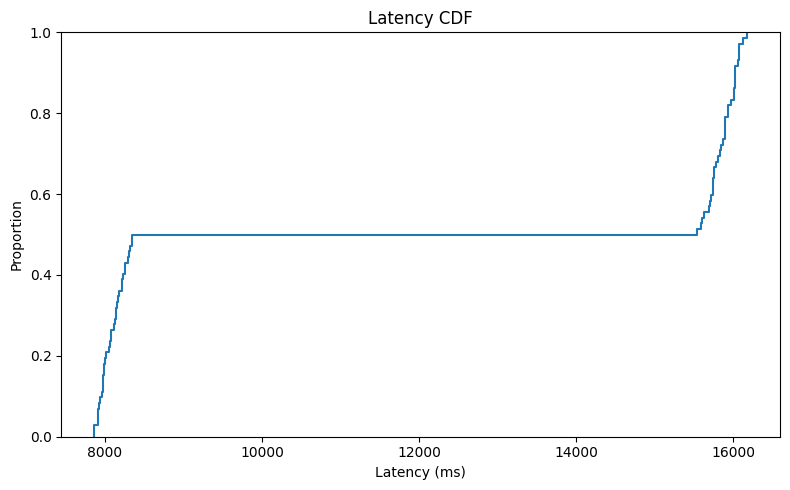

In [12]:
%matplotlib inline

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(f"./npf-out/{now}.csv")

# fig, ax = plt.subplots(figsize=(8, 5))
# sns.lineplot(
#     data=df,
#     x="ADDITIONAL_DATA_SIZE",
#     y="y_LATENCY",
#     markers=True,
#     errorbar="sd",
#     ax=ax,
# )
# ax.set_xlabel("Additional Data Size")
# ax.set_ylabel("Latency (ms)")
# ax.set_title("Latency vs Additional Data Size")
# plt.tight_layout()
# plt.savefig("latency_vs_size.png", dpi=150)
# plt.show()

# plt.figure()
fig, ax = plt.subplots(figsize=(8, 5))
sns.ecdfplot(data=df, x="y_LATENCY", ax=ax)
ax.set_xlabel("Latency (ms)")
ax.set_title("Latency CDF")
plt.tight_layout()
# plt.savefig("latency_cdf.png", dpi=150)
plt.show()

### Dumping FRRouting config + tunnels

In [13]:
from pathlib import Path
from datetime import datetime
import subprocess

DUMP_ROOT = Path("./node_config_dumps") / datetime.now().strftime("%Y%m%d_%H%M%S")
DUMP_ROOT.mkdir(parents=True, exist_ok=True)

ROLES_TO_DUMP = ["router"]
COMMANDS = {
    "frr.conf.txt": "sudo cat /etc/frr/frr.conf",
    "frr.daemons.txt": "sudo cat /etc/frr/daemons",
    "ip_addr.txt": "ip -br addr",
    "ip_route.txt": "ip route show",
    "ip_tunnel.txt": "ip tunnel show",
}

def ssh_capture(host, command):
    return subprocess.run(
        ["ssh", f"root@{host}", command],
        capture_output=True,
        text=True,
    )

for role in ROLES_TO_DUMP:
    if role not in roles:
        continue

    role_dir = DUMP_ROOT / role
    role_dir.mkdir(parents=True, exist_ok=True)

    for node in roles[role]:
        host = node.address
        node_name = (getattr(node, "alias", host) or host).replace("/", "_")
        node_dir = role_dir / node_name
        node_dir.mkdir(parents=True, exist_ok=True)

        (node_dir / "node.txt").write_text(
            f"role={role}\nalias={getattr(node, 'alias', '')}\naddress={host}\n",
            encoding="utf-8",
        )

        for output_name, cmd in COMMANDS.items():
            result = ssh_capture(host, cmd)
            out_file = node_dir / output_name

            if result.returncode == 0:
                out_file.write_text(result.stdout, encoding="utf-8")
            else:
                out_file.write_text(
                    "\n".join(
                        [
                            f"Command failed with return code {result.returncode}",
                            f"$ {cmd}",
                            "",
                            "STDERR:",
                            result.stderr,
                            "",
                            "STDOUT:",
                            result.stdout,
                        ]
                    ),
                    encoding="utf-8",
                )

        # make a full copy of /etc/frr as an archive just in case
        frr_archive_path = node_dir / "etc_frr.tar.gz"
        with frr_archive_path.open("wb") as archive_file:
            archive_result = subprocess.run(
                ["ssh", "root","@", host, "sudo tar -C /etc -czf - frr"],
                stdout=archive_file,
                stderr=subprocess.PIPE,
            )

        if archive_result.returncode != 0:
            (node_dir / "etc_frr_archive_error.txt").write_text(
                archive_result.stderr.decode("utf-8", errors="replace"),
                encoding="utf-8",
            )

        print(f"Dumped configs for {host} in {node_dir}")


Dumped configs for parasilo-14.rennes.grid5000.fr in node_config_dumps/20260412_231406/router/parasilo-14.rennes.grid5000.fr
Dumped configs for fleckenstein-1.strasbourg.grid5000.fr in node_config_dumps/20260412_231406/router/fleckenstein-1.strasbourg.grid5000.fr
Dumped configs for econome-20.nantes.grid5000.fr in node_config_dumps/20260412_231406/router/econome-20.nantes.grid5000.fr


### Stopping the current booking

In [14]:
provider.destroy()

INFO     [G5k] Reloading 312835 from nantes                              ]8;id=701398;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=198276;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Reloading 3692329 from rennes                             ]8;id=351026;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=136868;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Reloading 41921 from strasbourg                           ]8;id=944744;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=303796;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#167\167]8;;\

INFO     [G5k] Killing the job (nantes, 312835)                          ]8;id=997291;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=382703;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#276\276]8;;\

INFO     [G5k] Job killed (nantes, 312835)                               ]8;id=869939;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=580568;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#257\257]8;;\

INFO     [G5k] Killing the job (rennes, 3692329)                         ]8;id=589584;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=416316;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#276\276]8;;\

INFO     [G5k] Job killed (rennes, 3692329)                              ]8;id=964557;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=449273;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#257\257]8;;\

INFO     [G5k] Killing the job (strasbourg, 41921)                       ]8;id=117911;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=378564;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#276\276]8;;\

INFO     [G5k] Job killed (strasbourg, 41921)                            ]8;id=916676;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py\g5k_api_utils.py]8;;\:]8;id=465983;file:///home/corentin/.local/lib/python3.12/site-packages/enoslib/infra/enos_g5k/g5k_api_utils.py#257\257]8;;\